# 04 . SOFR curve and European swaption (Part II)

A European **payer** swaption: the right, in 2 years, to enter a 5-year swap paying 4.5% fixed and
receiving floating, semi-annual payments, forward swap rate volatility 15%, notional \$100,
continuous compounding.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.float_format = "{:.6f}".format

In [2]:
from curve import SofrCurve, TERM_SOFR, SWAP_RATES
from swaps import par_swap_rate
from swaptions import black_swaption, black_vega

curve = SofrCurve.from_csv(Path.cwd().parent / "data" / "sofr_2026-10-01.csv")
mkt = pd.DataFrame({"rate": list(TERM_SOFR.values()) + list(SWAP_RATES.values()),
                    "source": ["CME Term SOFR"] * len(TERM_SOFR) + ["SOFR OIS swap"] * len(SWAP_RATES)},
                   index=["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y"])
mkt.style.format({"rate": "{:.4%}"})

,rate,source
1M,3.9163%,CME Term SOFR
3M,4.0473%,CME Term SOFR
6M,4.2258%,CME Term SOFR
1Y,4.5446%,CME Term SOFR
2Y,4.5900%,SOFR OIS swap
3Y,4.6800%,SOFR OIS swap
5Y,4.7100%,SOFR OIS swap
7Y,4.7500%,SOFR OIS swap
10Y,4.8300%,SOFR OIS swap


## Part II(a): curve construction

* **Short end ($T \le 1$y)** — Term SOFR simple ACT/360 rates: $y(T) = \frac1T\ln\left(1 + R\,\frac{365\,T}{360}\right)$.
* **Long end ($T \ge 2$y)** — bootstrap annual par swap rates:
  $P(0,n) = \dfrac{1 - S_n\sum_{i<n}P(0,i)}{1+S_n}$, with 4y, 6y, 8y, 9y swap rates linearly interpolated
  and $P(0,1)$ from the 1Y Term SOFR rate.
* **Between nodes** — linear interpolation of zero rates, $P(0,T) = e^{-y(T)\,T}$.

In [3]:
curve.nodes().style.format({"zero_rate": "{:.4%}", "discount": "{:.6f}"})

,source,zero_rate,discount
T,,,
0.083333,Term SOFR,3.9641%,0.996702
0.250000,Term SOFR,4.0826%,0.989845
0.500000,Term SOFR,4.2392%,0.979027
1.000000,Term SOFR,4.5047%,0.955952
2.000000,OIS swap,4.4874%,0.914162
3.000000,OIS swap,4.5776%,0.871684
4.000000,OIS swap (interp.),4.5920%,0.832201
5.000000,OIS swap,4.6070%,0.794255
6.000000,OIS swap (interp.),4.6278%,0.757550


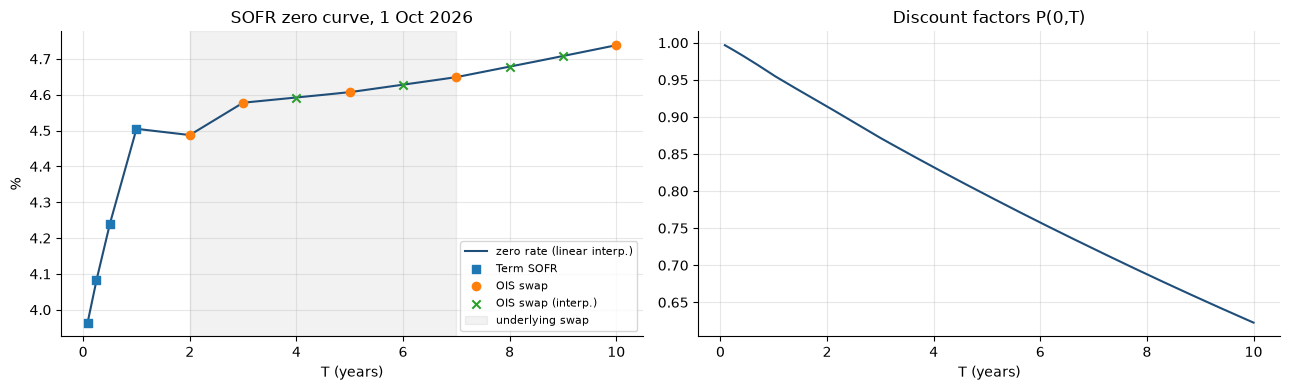

In [4]:
T_grid = np.linspace(1 / 12, 10, 400)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(T_grid, curve.zero_rate(T_grid) * 100, color="#1f4e79", label="zero rate (linear interp.)")
nodes = curve.nodes()
for src, mk in [("Term SOFR", "s"), ("OIS swap", "o"), ("OIS swap (interp.)", "x")]:
    sub = nodes[nodes.source == src]
    axes[0].scatter(sub.index, sub.zero_rate * 100, marker=mk, zorder=3, label=src)
axes[0].axvspan(2, 7, color="grey", alpha=0.1, label="underlying swap")
axes[0].set_xlabel("T (years)"); axes[0].set_ylabel("%"); axes[0].set_title("SOFR zero curve, 1 Oct 2026")
axes[0].legend(fontsize=8)
axes[1].plot(T_grid, curve.discount(T_grid), color="#1f4e79")
axes[1].set_xlabel("T (years)"); axes[1].set_title("Discount factors P(0,T)")
plt.tight_layout(); plt.show()

In [5]:
# the curve reprices its inputs
pd.DataFrame({"market": list(curve.swap_rates.values()),
              "repriced": [par_swap_rate(curve.discount, T, 1.0) for T in curve.swap_rates]},
             index=pd.Index(list(curve.swap_rates), name="swap tenor")).style.format("{:.4%}")

,market,repriced
swap tenor,,
2.000000,4.5900%,4.5900%
3.000000,4.6800%,4.6800%
5.000000,4.7100%,4.7100%
7.000000,4.7500%,4.7500%
10.000000,4.8300%,4.8300%


## Part II(b): Black's formula

$$A = \sum_{i=1}^{10}\tau_i P(0,T_i),\qquad S_0 = \frac{P(0,T_0) - P(0,T_n)}{A},$$
$$V_{payer} = N\,A\,\big[S_0\,\Phi(d_+) - K\,\Phi(d_-)\big],\qquad
d_\pm = \frac{\ln(S_0/K) \pm \tfrac12\nu^2T_0}{\nu\sqrt{T_0}}.$$

In [6]:
spec = dict(notional=100.0, K=0.045, T0=2.0, swap_tenor=5.0, freq=0.5, vol=0.15)
res = black_swaption(**spec, discount=curve.discount, payer=True)

grid = curve.table(np.r_[spec["T0"], res["payment_times"]])
display(grid.style.format({"y(T)": "{:.4%}", "P(0,T)": "{:.6f}"}))

pd.Series({"Annuity A": f"{res['annuity']:.6f}",
           "Forward swap rate S0": f"{res['forward_swap_rate']:.4%}",
           "d+": f"{res['d_plus']:.6f}", "d-": f"{res['d_minus']:.6f}",
           "Phi(d+)": f"{res['N(d_plus)']:.6f}", "Phi(d-)": f"{res['N(d_minus)']:.6f}",
           "Payer swaption value": f"${res['value']:.4f}",
           "  intrinsic N A (S0 - K)": f"${res['intrinsic']:.4f}",
           "  time value": f"${res['time_value']:.4f}",
           "Vega (per 1 vol point)": f"${black_vega(**spec, discount=curve.discount) / 100:.4f}",
           }).to_frame("value")

,y(T),"P(0,T)"
T,,
2.000000,4.4874%,0.914162
2.500000,4.5325%,0.892872
3.000000,4.5776%,0.871684
3.500000,4.5848%,0.851744
4.000000,4.5920%,0.832201
4.500000,4.5995%,0.813037
5.000000,4.6070%,0.794255
5.500000,4.6174%,0.775726
6.000000,4.6278%,0.757550


,value
Annuity A,4.025500
Forward swap rate S0,4.7682%
d+,0.378943
d-,0.166811
Phi(d+),0.647635
Phi(d-),0.566241
Payer swaption value,$2.1736
intrinsic N A (S0 - K),$1.0795
time value,$1.0940
Vega (per 1 vol point),$0.1008


Receiver swaption: $1.0940
Payer - receiver = 1.0795 = N A (S0 - K) = 1.0795  (parity)


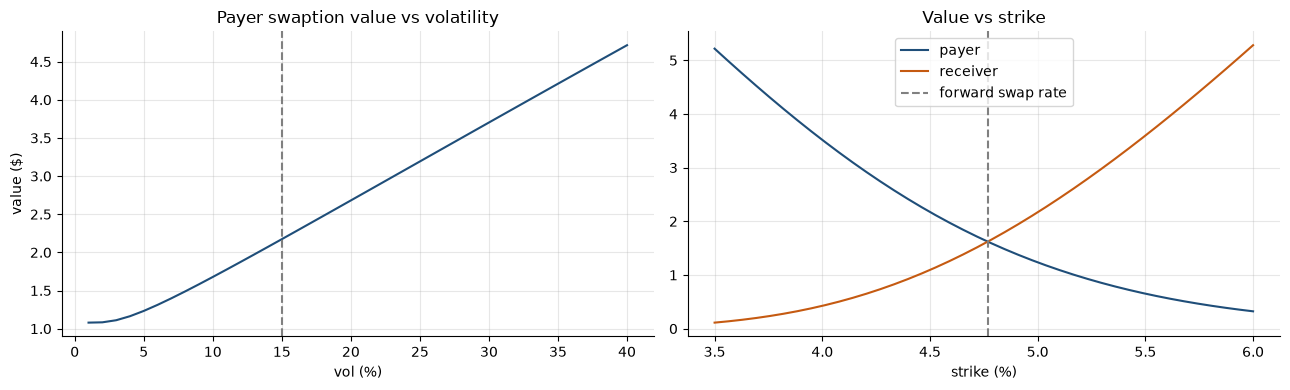

In [7]:
rec = black_swaption(**spec, discount=curve.discount, payer=False)
print(f"Receiver swaption: ${rec['value']:.4f}")
print(f"Payer - receiver = {res['value'] - rec['value']:.4f} = N A (S0 - K) = "
      f"{100 * res['annuity'] * (res['forward_swap_rate'] - 0.045):.4f}  (parity)")

vols = np.linspace(0.01, 0.40, 40)
strikes = np.linspace(0.035, 0.06, 40)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(vols * 100, [black_swaption(**{**spec, "vol": v}, discount=curve.discount)["value"] for v in vols],
             color="#1f4e79")
axes[0].axvline(15, color="grey", ls="--"); axes[0].set_xlabel("vol (%)"); axes[0].set_ylabel("value ($)")
axes[0].set_title("Payer swaption value vs volatility")
for payer, c in [(True, "#1f4e79"), (False, "#c55a11")]:
    axes[1].plot(strikes * 100, [black_swaption(**{**spec, "K": k}, discount=curve.discount, payer=payer)["value"]
                                 for k in strikes], color=c, label="payer" if payer else "receiver")
axes[1].axvline(res["forward_swap_rate"] * 100, color="grey", ls="--", label="forward swap rate")
axes[1].set_xlabel("strike (%)"); axes[1].set_title("Value vs strike"); axes[1].legend()
plt.tight_layout(); plt.show()

**Comments.** The forward swap rate (≈4.77%) is above the 4.5% strike, so the payer swaption is in the
money: about half of its value is intrinsic, $N A (S_0-K)$, the rest is time value from volatility.
$S_0$ is close to the 7-year par rate because the curve is nearly flat between 2 and 7 years.

## Part II(c): numeraire and the European swaption

A **numeraire** is a strictly positive traded asset $N(t)$ in whose units prices are expressed. For every
numeraire there is an equivalent martingale measure $Q^N$ under which every traded price divided by
$N$ is a martingale:

$$\frac{V(t)}{N(t)} = E^{Q^N}\left[\frac{V(T)}{N(T)}\,\middle|\,\mathcal F_t\right].$$

The choice is a tool: pick the numeraire that makes the payoff simplest. For a European swaption the
natural choice is the **annuity** $A(t) = \sum_i \tau_i P(t,T_i)$ (the PV01 of the fixed leg). The
payoff is $V(T_0) = N\,A(T_0)\max(S(T_0)-K,0)$, so

$$V(0) = N\,A(0)\,E^{Q^A}\big[\max(S(T_0)-K,0)\big],$$

and since $S(t) = \frac{P(t,T_0)-P(t,T_n)}{A(t)}$ is a traded asset over the numeraire, it is a
$Q^A$-martingale. Assuming it is lognormal, $dS = \nu S\,dW^A$, gives Black's formula above.

## Part II(d): numeraire for a Bermudan swaption

A Bermudan swaption can be exercised on several dates $T_0, T_1, \dots, T_{M-1}$ into the swap ending at
$T_n$. Each exercise date has a different underlying swap and annuity, so no single annuity makes all
the exercise values simple. Standard choices are:

* the **bank account** $B(t) = e^{\int_0^t r(s)ds}$ (risk-neutral measure $Q$) — natural with a short-rate
  model such as Vasicek/Hull-White, on a tree, PDE grid or by simulation;
* the **spot / rolling LIBOR-SOFR numeraire** or the **terminal bond** $P(t,T_n)$ (terminal forward measure)
  in a LIBOR/SOFR market model — the counterpart of the annuity measure that works across all dates.

Valuation is by backward induction (dynamic programming) on the exercise dates:

$$V(T_k) = \max\Big(\text{exercise value}(T_k),\; N(T_k)\,E^{Q^N}\Big[\frac{V(T_{k+1})}{N(T_{k+1})}\Big|\mathcal F_{T_k}\Big]\Big),$$

with exercise value $N\,A_k(T_k)\max(S_k(T_k) - K, 0)$ for a payer. On a lattice the continuation
value is computed exactly; with Monte Carlo it is estimated by **Longstaff-Schwartz** regression of the
discounted future cash flows on functions of the state (e.g. $r$, the swap rate). The Bermudan value is
at least the most valuable of the co-terminal European swaptions.